<a href="https://colab.research.google.com/github/FShuen/Classifier/blob/master/2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
from sklearn import svm
from sklearn import metrics
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
from tensorflow import keras
import random as rd
from scipy import signal
from keras.utils import np_utils

from keras.models import Sequential
from keras.layers import LSTM,Dense,Dropout,Flatten,Conv2D,MaxPooling2D,GlobalAveragePooling2D,BatchNormalization,AveragePooling2D
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau

In [82]:
excel_1 = "https://github.com/FShuen/ECE_Project_2021/raw/master/train8.xlsx"
train = pd.read_excel(excel_1,header = None, sheet_name = 0)



(1374, 300)

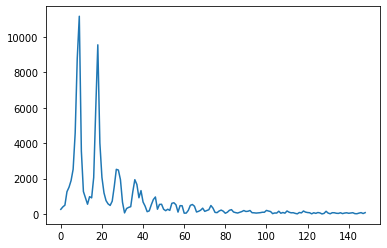

In [83]:
y1 = np.swapaxes(train[:][0:300], 0, 1)

b, a = signal.butter(8, 0.02, 'highpass')   #配置濾波器 8 表示濾波器的階數
y1 = signal.filtfilt(b, a, y1)

y1_fft = np.abs(np.fft.rfft(y1))

plt.plot(y1_fft[0, 1:150])
y1.shape

In [84]:
num_1 = train.shape[1]

size = 200
cut = 20
size_2 = size - cut * 2

In [85]:
from matplotlib.backends.backend_agg import FigureCanvasAgg
from matplotlib.figure import Figure

fig = Figure(figsize=(3, 3), dpi = size/3)

canvas = FigureCanvasAgg(fig)

img_1 = np.zeros(shape = (num_1, size, size, 4), dtype = int)

ax = fig.add_subplot()

for i in range(0, num_1):
    ax.plot(y1_fft[i, 0:150], color = 'black')
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 16000])
    ax.axis("off")
    canvas.draw()
    buf = canvas.buffer_rgba()
    img_1[i] = np.asarray(buf)
    ax.clear()
    
print(img_1[0])

[[[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 ...

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]

 [[255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]
  ...
  [255 255 255   0]
  [255 255 255   0]
  [255 255 255   0]]]


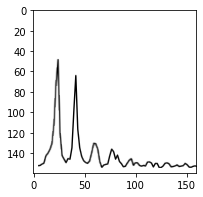

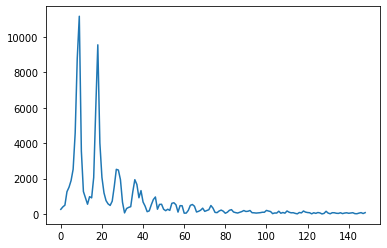

In [86]:
def plot_image(image):
    plt.clf()
    fig = plt.gcf()
    fig.set_size_inches(3, 3)
    plt.imshow(image, cmap='binary')
    plt.show()
    
plot_image(img_1[0, cut:size-cut, cut:size-cut])
plt.plot(y1_fft[0, 1:150])
plt.show()

In [87]:
def rgba(image):
    new_img = np.zeros(shape = (size_2, size_2, 1), dtype = int)
    for i in range(0, size_2):
        for j in range(0, size_2):
            if image[i + cut, j + cut, 0] < 255:
                new_img[i, j, 0] = 1
    return new_img

In [88]:
img_rgba1 = np.zeros(shape = (num_1, size_2, size_2, 1), dtype = int)
for i in range(0, num_1):
    img_rgba1[i] = rgba(img_1[i])

In [89]:
# plot_image(img_rgba1[0])

In [90]:
# plot_image(img_1[0])

In [91]:
labels_1 = np.swapaxes(train, 0, 1)[304]

labels_onehot1 = np_utils.to_categorical(labels_1)

labels_onehot1.shape

(1374, 36)

In [92]:
index = np.arange(0, num_1, dtype = int)
rd.shuffle(index)
img_rgba1 = img_rgba1[index]
labels_onehot1 = labels_onehot1[index]

In [93]:
excel_2 = "https://github.com/FShuen/ECE_Project_2021/raw/master/test8.xlsx"
test = pd.read_excel(excel_2,header = None, sheet_name = 0)
# , usecols = 'A:HS'
test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,660,661,662,663,664,665,666,667,668,669,670,671,672,673,674,675,676,677,678,679,680,681,682,683,684,685,686,687,688,689,690,691,692,693,694,695,696,697,698,699
0,35115.0,34856.0,35398.0,34462.0,35153.0,35457.0,33382.0,34538.0,35012.0,34985.0,33928.0,33260.0,35078.0,34978.0,34924.0,33848.0,34242.0,34512.0,34729.0,34400.0,35169.0,35085.0,34722.0,34737.0,34473.0,34445.0,34457.0,34573.0,34412.0,34788.0,34704.0,33622.0,33950.0,33760.0,31521.0,31368.0,32040.0,31785.0,31647.0,31732.0,...,27844.0,27931.0,27567.0,27373.0,28051.0,27722.0,27015.0,26444.0,26364.0,26460.0,26321.0,27369.0,27146.0,27192.0,27114.0,27024.0,26828.0,27044.0,26889.0,26738.0,27413.0,27018.0,26895.0,26775.0,26906.0,29806.0,29979.0,29822.0,29828.0,29577.0,29496.0,29361.0,29285.0,29654.0,29577.0,29106.0,28819.0,29448.0,29461.0,29329.0
1,35119.0,34866.0,35413.0,34484.0,35171.0,35367.0,33246.0,34554.0,35040.0,35015.0,33944.0,33269.0,35094.0,35008.0,34898.0,33743.0,34251.0,34491.0,34751.0,34401.0,35204.0,34880.0,34761.0,34763.0,34493.0,34459.0,34488.0,34581.0,34405.0,34811.0,34722.0,33636.0,33964.0,33765.0,31552.0,31342.0,31949.0,31818.0,31673.0,31647.0,...,27845.0,27935.0,27569.0,27370.0,28054.0,27729.0,27000.0,26437.0,26375.0,26465.0,26322.0,27373.0,27149.0,27194.0,27121.0,27031.0,26831.0,27052.0,26887.0,26739.0,27420.0,27014.0,26902.0,26776.0,26913.0,29809.0,29992.0,29822.0,29836.0,29577.0,29505.0,29360.0,29283.0,29657.0,29589.0,29097.0,28819.0,29441.0,29470.0,29337.0
2,35113.0,34884.0,35415.0,34500.0,35193.0,35210.0,33025.0,34564.0,35064.0,35031.0,33955.0,33281.0,35111.0,35029.0,34892.0,33693.0,34228.0,34494.0,34771.0,34411.0,35236.0,34728.0,34790.0,34782.0,34512.0,34479.0,34527.0,34605.0,34424.0,34836.0,34751.0,33656.0,33970.0,33763.0,31578.0,31339.0,31848.0,31837.0,31696.0,31567.0,...,27849.0,27935.0,27565.0,27371.0,28056.0,27728.0,26989.0,26428.0,26382.0,26474.0,26321.0,27372.0,27152.0,27193.0,27120.0,27031.0,26835.0,27051.0,26890.0,26743.0,27424.0,27020.0,26911.0,26777.0,26918.0,29816.0,29999.0,29816.0,29833.0,29585.0,29518.0,29357.0,29278.0,29666.0,29594.0,29098.0,28813.0,29451.0,29480.0,29338.0
3,35107.0,34895.0,35349.0,34506.0,35200.0,35129.0,32896.0,34575.0,35090.0,35051.0,33972.0,33301.0,35131.0,35039.0,34900.0,33676.0,34080.0,34510.0,34795.0,34429.0,35259.0,34672.0,34797.0,34808.0,34543.0,34501.0,34571.0,34615.0,34458.0,34859.0,34771.0,33677.0,33976.0,33766.0,31596.0,31340.0,31768.0,31867.0,31727.0,31517.0,...,27849.0,27935.0,27567.0,27366.0,28057.0,27729.0,26985.0,26424.0,26389.0,26476.0,26324.0,27369.0,27158.0,27190.0,27120.0,27034.0,26835.0,27051.0,26895.0,26750.0,27426.0,27025.0,26918.0,26787.0,26928.0,29819.0,30009.0,29821.0,29830.0,29586.0,29528.0,29361.0,29278.0,29675.0,29599.0,29113.0,28808.0,29463.0,29495.0,29346.0
4,35107.0,34913.0,35210.0,34443.0,35221.0,35082.0,32844.0,34581.0,35103.0,35072.0,33988.0,33325.0,35160.0,35035.0,34917.0,33678.0,33890.0,34533.0,34825.0,34458.0,35278.0,34656.0,34810.0,34845.0,34565.0,34536.0,34604.0,34647.0,34489.0,34892.0,34802.0,33699.0,33976.0,33776.0,31599.0,31348.0,31710.0,31892.0,31752.0,31488.0,...,27851.0,27936.0,27566.0,27372.0,28060.0,27729.0,26984.0,26426.0,26395.0,26483.0,26329.0,27358.0,27161.0,27193.0,27118.0,27040.0,26839.0,27047.0,26900.0,26754.0,27430.0,27030.0,26919.0,26793.0,26939.0,29829.0,30020.0,29822.0,29828.0,29589.0,29540.0,29369.0,29284.0,29688.0,29609.0,29129.0,28810.0,29475.0,29505.0,29352.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...

In [94]:
num_2 = test.shape[1]
num_2

700

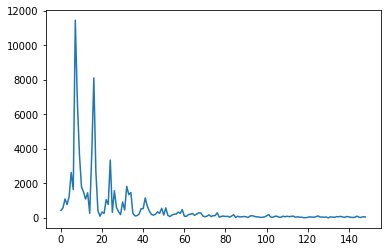

In [95]:
y2 = np.swapaxes(test[:][0:300], 0, 1)

y2 = signal.filtfilt(b, a, y2)

y2_fft = np.abs(np.fft.rfft(y2))  #快速傅里葉變換

plt.plot(y2_fft[0, 1:150])

In [96]:
img_2 = np.zeros(shape = (num_2, size, size, 4), dtype = int)
for i in range(0, num_2):
    ax.plot(y2_fft[i, 0:150], color = 'black')
    ax.set_xlim([0, 80])
    ax.set_ylim([0, 16000])
    ax.axis("off")
    canvas.draw()
    buf = canvas.buffer_rgba()
    img_2[i] = np.asarray(buf)
    ax.clear()

In [97]:
img_rgba2 = np.zeros(shape = (num_2, size_2, size_2, 1), dtype = int)
for i in range(0, num_2):
    img_rgba2[i] = rgba(img_2[i])

In [98]:
labels_2 = np.swapaxes(test, 0, 1)[304]

labels_onehot2 = np_utils.to_categorical(labels_2)

labels_2

0       1.0
1       1.0
2       1.0
3       1.0
4       1.0
       ... 
695    35.0
696    35.0
697    35.0
698    35.0
699    35.0
Name: 304, Length: 700, dtype: float64

In [99]:
# 從這行向下執行
k_s1 = 3
k_s2 = 3
k_s3 = 3
b_s = 2
ep = 100
keras.backend.clear_session()

In [100]:
model = Sequential()

In [101]:
#filter為16, Kernel size為(5,5),Padding為(same)
model.add(Conv2D(filters = 12,
                 kernel_size = (k_s1, k_s1),
                 padding = 'same',
                 input_shape = (size_2, size_2, 1),
                 activation = 'relu'))


In [102]:
# MaxPooling size為(2,2)
model.add(AveragePooling2D(pool_size=(2, 2)))
# model.add(BatchNormalization())
model.add(Dropout(0.2))


In [103]:
model.add(Conv2D(filters = 24,
                 kernel_size = (k_s2, k_s2),
                 padding = 'same',
                 activation = 'relu'))

In [104]:
# MaxPooling size為(2,2)
model.add(AveragePooling2D(pool_size=(2, 2)))
# model.add(BatchNormalization())
model.add(Dropout(0.2))

In [105]:
model.add(Conv2D(filters = 36,
                 kernel_size = (k_s3, k_s3),
                 padding = 'same',
                 activation = 'relu'))

In [106]:
# MaxPooling size為(2,2)
model.add(AveragePooling2D(pool_size=(2, 2)))


In [107]:
# Drop掉部分神經元避免overfitting
model.add(Dropout(0.1))

In [108]:
model.add(Conv2D(filters = 48,
                 kernel_size = (k_s3, k_s3),
                 padding = 'same',
                 activation = 'relu'))
model.add(AveragePooling2D(pool_size=(2, 2)))
model.add(Dropout(0.1))

In [109]:
# 平坦化
model.add(Flatten())
# model.add(GlobalAveragePooling2D())

In [110]:
# model.add(Dense(64, activation = 'relu'))

In [111]:
# model.add(Dropout(0.25))
# model.add(Dense(256,activation='relu'))
model.add(Dense(128,activation='relu'))
# model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))

In [112]:
model.add(Dense(labels_1[num_1 - 1] + 1, activation='softmax'))

In [113]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 160, 160, 12)      120       
_________________________________________________________________
average_pooling2d (AveragePo (None, 80, 80, 12)        0         
_________________________________________________________________
dropout (Dropout)            (None, 80, 80, 12)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 80, 80, 24)        2616      
_________________________________________________________________
average_pooling2d_1 (Average (None, 40, 40, 24)        0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 40, 40, 24)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 40, 40, 36)        7

In [114]:
opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss = 'categorical_crossentropy', optimizer = opt ,metrics=['accuracy'])

In [115]:
earlystop = EarlyStopping(monitor='val_loss', patience=100, verbose=1)
learning_rate_function = ReduceLROnPlateau(monitor='val_loss', 
                                            patience=6, 
                                            verbose=1, 
                                            factor=0.5, 
                                            min_lr=0.000000001)

train_history = model.fit(x = img_rgba1, 
                          y = labels_onehot1, validation_split = 0.1, 
                          epochs = ep, batch_size = b_s, verbose = 2, callbacks = [earlystop, learning_rate_function])

Epoch 1/100
618/618 - 4s - loss: 2.8720 - accuracy: 0.1715 - val_loss: 1.9382 - val_accuracy: 0.3333
Epoch 2/100
618/618 - 3s - loss: 1.4654 - accuracy: 0.5291 - val_loss: 1.0559 - val_accuracy: 0.7029
Epoch 3/100
618/618 - 3s - loss: 1.0103 - accuracy: 0.6634 - val_loss: 0.8759 - val_accuracy: 0.7464
Epoch 4/100
618/618 - 3s - loss: 0.7641 - accuracy: 0.7379 - val_loss: 0.7128 - val_accuracy: 0.7536
Epoch 5/100
618/618 - 3s - loss: 0.5775 - accuracy: 0.8123 - val_loss: 0.5364 - val_accuracy: 0.8333
Epoch 6/100
618/618 - 3s - loss: 0.4755 - accuracy: 0.8479 - val_loss: 0.6904 - val_accuracy: 0.8116
Epoch 7/100
618/618 - 3s - loss: 0.4019 - accuracy: 0.8665 - val_loss: 0.5457 - val_accuracy: 0.8333
Epoch 8/100
618/618 - 3s - loss: 0.3631 - accuracy: 0.8681 - val_loss: 0.4243 - val_accuracy: 0.8623
Epoch 9/100
618/618 - 3s - loss: 0.2862 - accuracy: 0.8964 - val_loss: 0.5117 - val_accuracy: 0.8478
Epoch 10/100
618/618 - 3s - loss: 0.3103 - accuracy: 0.8940 - val_loss: 0.5860 - val_accura

In [116]:
def show_train_history(train_acc,test_acc):
    plt.clf()
    plt.plot(train_history.history[train_acc])
    plt.plot(train_history.history[test_acc])
    plt.title('Train History')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['train', 'test'], loc='upper left')
    plt.show()

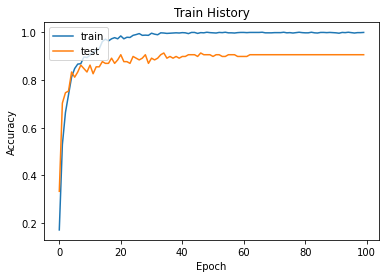

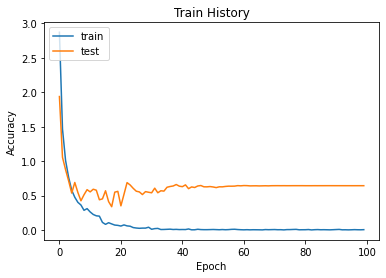

In [117]:
show_train_history('accuracy','val_accuracy')
show_train_history('loss','val_loss')

In [118]:
scores = model.evaluate(img_rgba2 ,labels_onehot2)
scores[1]

22/22 [==============================] - 1s 16ms/step - loss: 0.2167 - accuracy: 0.9600


0.9599999785423279

In [119]:
prediction=model.predict(img_rgba2)
classes_x=np.argmax(prediction,axis=1)

In [120]:
classes_x

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, 13,  2,  2,
        2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,
        2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,  3,
        4,  3,  3,  4,  4,  4, 10,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,
        4,  4,  4,  4,  5,  5,  5,  5,  5,  1,  5,  5,  5,  5,  5,  5,  5,
        5,  5,  5,  5,  5,  5,  5, 19,  5,  6, 26,  6,  6,  6,  6,  6,  6,
        6,  6,  6,  6,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,  7,
        7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9,
        9,  9,  9,  9,  9,  9,  9, 10, 10, 10, 10, 10, 10, 10, 10, 31, 10,
       10, 10, 10, 10, 10